In [22]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler, OrdinalEncoder
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
import xgboost as xgb
from tqdm.notebook import tqdm
import shap

In [23]:
data = 'dataset/df_feature_engineered_no_god_mode.csv'
index_col = 0
df = pd.read_csv(data, sep=',', index_col=index_col)

pd.set_option('display.max_columns', None)

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11166 entries, TR934808 to TR552777
Data columns (total 69 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   id_artist                      11166 non-null  object 
 1   name_artist                    11166 non-null  object 
 2   title                          11166 non-null  object 
 3   featured_artists               11166 non-null  object 
 4   language                       11032 non-null  object 
 5   swear_IT                       11166 non-null  int64  
 6   swear_EN                       11166 non-null  int64  
 7   swear_IT_words                 11166 non-null  object 
 8   swear_EN_words                 11166 non-null  object 
 9   n_sentences                    10959 non-null  float64
 10  n_tokens                       10959 non-null  float64
 11  tokens_per_sent                10959 non-null  float64
 12  char_per_tok                   11090 non-

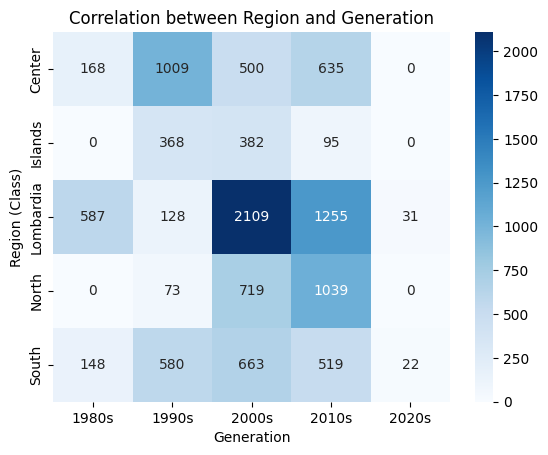

In [25]:
# Check the overlap between your Target (Region) and the Feature (Generation)
crosstab = pd.crosstab(df['macro_region'], df['Artist_Generation'])

# Visualize it
sns.heatmap(crosstab, annot=True, fmt='d', cmap='Blues')
plt.title("Correlation between Region and Generation")
plt.xlabel("Generation")
plt.ylabel("Region (Class)")
plt.show()

In [26]:
df['gender'] = df['gender'].astype('category')
df['nationality'] = df['nationality'].astype('category')
df['country'] = df['country'].astype('category')
df['region'] = df['region'].astype('category')
df['province'] = df['province'].astype('category')
df['birth_place'] = df['birth_place'].astype('category')
df['birth_date'] = pd.to_datetime(df['birth_date'], errors='coerce')
df['active_start'] = pd.to_datetime(df['active_start'], errors='coerce')
df['description'] = df['description'].astype('string')

In [27]:
df['id_artist'] = df['id_artist'].astype('category')
df['id_album'] = df['id_album'].astype('category')
df['language'] = df['language'].astype('category')
df['album_type'] = df['album_type'].astype('category')
df['popularity'] = pd.to_numeric(df['popularity'], errors = 'coerce').astype('Int64')
df['n_sentences'] = df['n_sentences'].astype('Int64')
df['n_tokens'] = df['n_tokens'].astype('Int64')
df['disc_number'] = df['disc_number'].astype('Int64')
df['track_number'] = df['track_number'].astype('Int64')
df['explicit'] = df['explicit'].astype('boolean')
df['has_featured_artist'] = df['has_featured_artist'].astype('boolean')
df['name_artist'] = df['name_artist'].astype('string')
df['title'] = df['title'].astype('string')
df['album'] = df['album'].astype('string')
df['album_image'] = df['album_image'].astype('string')
df['lyrics'] = df['lyrics'].astype('string')
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['Artist_Generation'] = df['Artist_Generation'].astype('category')

In [28]:
df = df.dropna(subset=['macro_region']).copy()

In [29]:
print("Class Distribution:")
print(df['macro_region'].value_counts())

Class Distribution:
macro_region
Lombardia    4110
Center       2312
South        1932
North        1831
Islands       845
Name: count, dtype: int64


In [30]:
# Assuming 'T-Shirt Size' is the categorical column
encoder = OrdinalEncoder(categories=[['1980s', '1990s', '2000s', '2010s', '2020s']]) # Define the order explicitly

# Reshape input as fit_transform requires a 2D array
df['artist_generation_encoded'] = encoder.fit_transform(df[['Artist_Generation']])

In [31]:
# Pass a list of prefixes matching the columns list
df_encoded = pd.get_dummies(
    df, 
    columns=['gender', 'has_featured_artist', 'primary_topic'], 
    prefix=['gender', 'has_featured_artist', 'primary_topic'],  # <--- Must be a list ['a', 'b']
    drop_first=True  # Recommended to prevent multicollinearity
)

In [32]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11030 entries, TR934808 to TR552777
Data columns (total 76 columns):
 #   Column                                Non-Null Count  Dtype         
---  ------                                --------------  -----         
 0   id_artist                             11030 non-null  category      
 1   name_artist                           11030 non-null  string        
 2   title                                 11030 non-null  string        
 3   featured_artists                      11030 non-null  object        
 4   language                              10922 non-null  category      
 5   swear_IT                              11030 non-null  int64         
 6   swear_EN                              11030 non-null  int64         
 7   swear_IT_words                        11030 non-null  object        
 8   swear_EN_words                        11030 non-null  object        
 9   n_sentences                           10849 non-null  Int64        

In [ ]:
# 2. Define Feature Lists
NUMERIC_FEATURES = [
    'bpm', 
    'centroid', 
    'rolloff', 
    'flux', 
    'rms', 
    'flatness', 
    'spectral_complexity', 
    'pitch', 
    'duration_ms', 
    'popularity', 
    'Swear_Rate',
    'n_sentences', 
    'tokens_per_sent', 
    'char_per_tok', 
    'lexical_density', 
    'score_love', 
    'score_crime', 
    'score_drugs', 
    'score_politics', 
    'score_sadness', 
    'score_sex',
    'entropy_lyrics',
    # 'Artist_Release_Entropy',
    # 'Centroid_Entropy',
    'Characters_Per_Minute',
    # 'mean_duration_song_per_album',
    'avg_token_per_clause'
]

CATEGORICAL_FEATURES = [
    'gender_M',
    # 'artist_generation_encoded',
    'has_featured_artist_True',
    # 'primary_topic_Drugs and Alcohol',        
    # 'primary_topic_Love and Relationships',        
    # 'primary_topic_Money and Success',             
    # 'primary_topic_Politics and Society',          
    # 'primary_topic_Sadness and Depression',        
    # 'primary_topic_Sex',                           
    # 'primary_topic_Too Short'
]

In [34]:
COLS = NUMERIC_FEATURES + CATEGORICAL_FEATURES

X = df_encoded[COLS].copy()
y = df_encoded['artist_generation_encoded'].copy()

data_combined = pd.concat([X, y], axis=1)

# --- 2. Define the Columns Used for Transformations (The source of your previous .dropna()) ---
# These are the columns where missing values were removed when you created X_preprocessed:
# Plus any other numeric features that were included in X but not in the log lists
# e.g., features where you ran an Imputer on later.

# --- 3. Filter the combined data based on missing values in the critical columns ---
# This replicates the effect of your previous X.copy().dropna()
data_aligned = data_combined.dropna(subset=COLS)

# --- 4. Separate X and y after alignment ---
X = data_aligned.drop(columns=['artist_generation_encoded'])
y = data_aligned['artist_generation_encoded']

# 4. Target Encoding
le = LabelEncoder()
y_encoded = le.fit_transform(y)
CLASS_NAMES = le.classes_

In [35]:
X_preprocessed = X.copy().dropna()

In [36]:
LOG_TRANSFORM_COLS = [
    'swear_IT',
    'swear_EN',
    'tokens_per_sent',
    'char_per_tok',
    'avg_token_per_clause',
    'duration_ms',
    'Characters_Per_Minute',
    'Swear_Rate',
    'mean_duration_song_per_album'
]
X_preprocessed = X.copy().dropna()

# 1. Apply the log(x+1) transformation using numpy.log1p
for col in LOG_TRANSFORM_COLS:
    # Ensure the column exists in the data subset before transforming
    if col in X_preprocessed.columns:
        # np.log1p(x) calculates log(x + 1)
        X_preprocessed[col] = np.log1p(X_preprocessed[col])

print("✅ Log Transformation applied to selected features in 'X_preprocessed'.")

✅ Log Transformation applied to selected features in 'X_preprocessed'.


In [37]:
# Define the columns that require the reflected log transform
REFLECTED_LOG_TRANSFORM_COLS = [
    'Artist_Release_Entropy',  # Replace with your actual column names
    'entropy_lyrics', 
    'Centroid_Entropy',
    'flatness'
]

for col in REFLECTED_LOG_TRANSFORM_COLS:
    
    if col in X_preprocessed.columns:
        
        # 1. Calculate the maximum value of the column (max(x))
        max_val = X_preprocessed[col].max()
        
        # 2. Define the shift constant C = max(x) + delta
        # Using C = max_val + 1 guarantees (C - x) > 0 for all values.
        C = max_val + 1
        
        # 3. Apply the reflection (C - x) and then the natural logarithm (np.log)
        X_preprocessed[col] = np.log(C - X_preprocessed[col])

print("✅ Reflected Log Transformation (log(C - x)) applied to features with negative skew.")
print(f"Values were reflected using C = max(x) + 1.")

✅ Reflected Log Transformation (log(C - x)) applied to features with negative skew.
Values were reflected using C = max(x) + 1.


In [38]:
# Convert the OHE DataFrame to a NumPy array for stacking
X_categorical_array = X_preprocessed[CATEGORICAL_FEATURES].values 

# --- 2. Scale Numeric Features ---
scaler = StandardScaler()
X_numeric_scaled = scaler.fit_transform(X_preprocessed[NUMERIC_FEATURES].values)

# --- 3. Combine/Stack the Data Horizontally ---
# Use numpy.hstack to combine the scaled numeric features with the encoded categorical features
X_final_preprocessed = np.hstack([
    X_numeric_scaled, 
    X_categorical_array
])

# Remove the extra list bracket you had in the original error
X_preprocessed_scaled = X_final_preprocessed 

print("✅ Data successfully combined into a single NumPy array for modeling.")
print(f"Final shape of X for modeling: {X_preprocessed_scaled.shape}")

✅ Data successfully combined into a single NumPy array for modeling.
Final shape of X for modeling: (10783, 25)


In [39]:
X_train, X_test, y_train, y_test = train_test_split(
    X_preprocessed_scaled, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

N_FOLDS = 4
cv_strategy = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

print(f"✅ Data Split: Train/CV set size = {X_train.shape[0]}, Test set size = {X_test.shape[0]}")
print(f"✅ Model selection will use {N_FOLDS}-Fold Cross-Validation on the training set.")

✅ Data Split: Train/CV set size = 8626, Test set size = 2157
✅ Model selection will use 4-Fold Cross-Validation on the training set.


--- Starting Evaluation on 6 Models ---
✅ Decision Tree   | CV F1: 0.4255 | Test F1: 0.4364
✅ KNN             | CV F1: 0.4517 | Test F1: 0.4603
✅ Naive Bayes     | CV F1: 0.0677 | Test F1: 0.0631
✅ Random Forest   | CV F1: 0.4836 | Test F1: 0.4880
✅ XGBoost         | CV F1: 0.5116 | Test F1: 0.5374


/home/nico/UNIPI/courses/DataMining/venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/nico/UNIPI/courses/DataMining/venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/nico/UNIPI/courses/DataMining/venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


✅ Neural Network  | CV F1: 0.4700 | Test F1: 0.5082

🏆 FINAL MODEL LEADERBOARD
            Model  CV Accuracy  CV F1 (Weighted)  Test Accuracy  \
4         XGBoost     0.527012          0.511554       0.549838   
5  Neural Network     0.473799          0.470050       0.513676   
3   Random Forest     0.519707          0.483607       0.522949   
1             KNN     0.466845          0.451669       0.476588   
0   Decision Tree     0.436819          0.425450       0.446917   
2     Naive Bayes     0.112103          0.067724       0.109875   

   Test F1 (Weighted)  
4            0.537386  
5            0.508164  
3            0.488006  
1            0.460282  
0            0.436442  
2            0.063056  

📊 Visualizing Confusion Matrices for Top 4 Models: ['XGBoost' 'Neural Network' 'Random Forest' 'KNN']


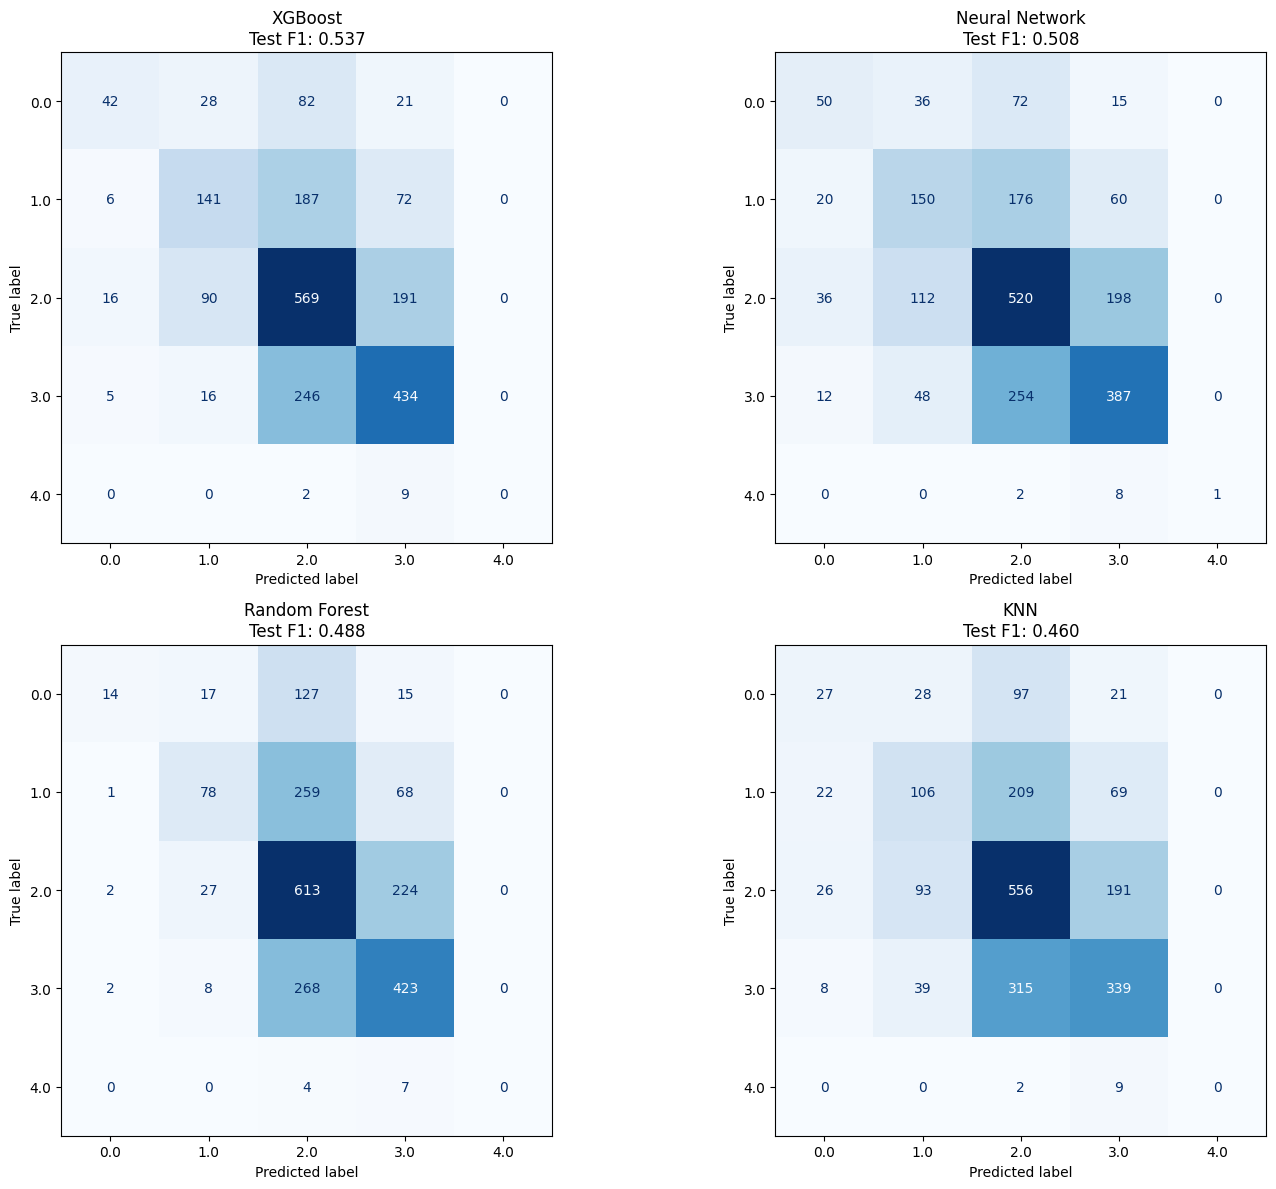


📝 Detailed Report for Best Model: XGBoost
              precision    recall  f1-score   support

         0.0       0.61      0.24      0.35       173
         1.0       0.51      0.35      0.41       406
         2.0       0.52      0.66      0.58       866
         3.0       0.60      0.62      0.61       701
         4.0       0.00      0.00      0.00        11

    accuracy                           0.55      2157
   macro avg       0.45      0.37      0.39      2157
weighted avg       0.55      0.55      0.54      2157



/home/nico/UNIPI/courses/DataMining/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/nico/UNIPI/courses/DataMining/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/nico/UNIPI/courses/DataMining/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mod

In [40]:
# --- 1. Define Models ---
models = {
    "Decision Tree": DecisionTreeClassifier(max_depth=10, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=10),
    "Naive Bayes": GaussianNB(),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42),
    "XGBoost": xgb.XGBClassifier(n_estimators=300, max_depth=None, eval_metric='mlogloss', random_state=42),
    "Neural Network": MLPClassifier(hidden_layer_sizes=(50, 20), max_iter=500, random_state=42)
}

# List to store summary metrics
model_performance = []

# Dictionary to store test predictions (for plotting CMs later)
test_predictions = {}

print(f"--- Starting Evaluation on {len(models)} Models ---")

# --- 2. Iterate through Models ---
for name, model in models.items():
    
    # A. Cross-Validation (Training Phase)
    # -------------------------------------------------------
    # We use cross_validate to get metrics for each fold
    cv_results = cross_validate(
        model, X_train, y_train, 
        cv=cv_strategy, 
        scoring=['accuracy', 'f1_weighted'],
        n_jobs=-1 # Use all CPU cores
    )
    
    cv_acc_mean = cv_results['test_accuracy'].mean()
    cv_f1_mean = cv_results['test_f1_weighted'].mean()
    
    # B. Test Set Evaluation (Final Phase)
    # -------------------------------------------------------
    # Fit on the entire training set
    model.fit(X_train, y_train)
    
    # Predict on the unseen test set
    y_test_pred = model.predict(X_test)
    test_predictions[name] = y_test_pred # Save for plotting
    
    # Calculate Test Metrics
    test_acc = accuracy_score(y_test, y_test_pred)
    test_f1 = f1_score(y_test, y_test_pred, average='weighted')
    
    # Save results to list
    model_performance.append({
        "Model": name,
        "CV Accuracy": cv_acc_mean,
        "CV F1 (Weighted)": cv_f1_mean,
        "Test Accuracy": test_acc,
        "Test F1 (Weighted)": test_f1
    })
    
    print(f"✅ {name: <15} | CV F1: {cv_f1_mean:.4f} | Test F1: {test_f1:.4f}")

# --- 3. Create & Display Summary Table ---
results_df = pd.DataFrame(model_performance).sort_values(by="Test F1 (Weighted)", ascending=False)

print("\n" + "="*50)
print("🏆 FINAL MODEL LEADERBOARD")
print("="*50)
print(results_df)


# --- 4. Plot Confusion Matrices (Grid) ---
# We will plot the top 4 models to save space

top_4_models = results_df.head(4)['Model'].values
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

print("\n" + "="*50)
print(f"📊 Visualizing Confusion Matrices for Top 4 Models: {top_4_models}")
print("="*50)

# Use class names from your LabelEncoder (ensure 'le' and 'y' are available from previous steps)
# If 'le' is missing, we can infer classes from y_encoded
display_labels = le.classes_

for i, model_name in enumerate(top_4_models):
    ax = axes[i]
    
    # Get predictions saved earlier
    y_pred = test_predictions[model_name]
    
    # Compute Matrix
    cm = confusion_matrix(y_test, y_pred)
    
    # Plot
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    
    ax.set_title(f"{model_name}\nTest F1: {results_df.loc[results_df['Model']==model_name, 'Test F1 (Weighted)'].values[0]:.3f}")

plt.tight_layout()
plt.show()

# --- 5. Detailed Classification Report for the #1 Best Model ---
best_model_name = results_df.iloc[0]['Model']
print(f"\n📝 Detailed Report for Best Model: {best_model_name}")

# FIX: Convert display_labels to strings to handle any potential floats/NaNs
target_names_str = [str(label) for label in display_labels]

print(classification_report(
    y_test, 
    test_predictions[best_model_name], 
    target_names=target_names_str
))

--- Starting Grid Search for KNN ---
Fitting 4 folds for each of 120 candidates, totalling 480 fits

✅ Best Parameters: {'metric': 'manhattan', 'n_neighbors': 11, 'weights': 'distance'}
✅ Best CV F1 Score: 0.4570
✅ Test Set F1 Score: 0.4901


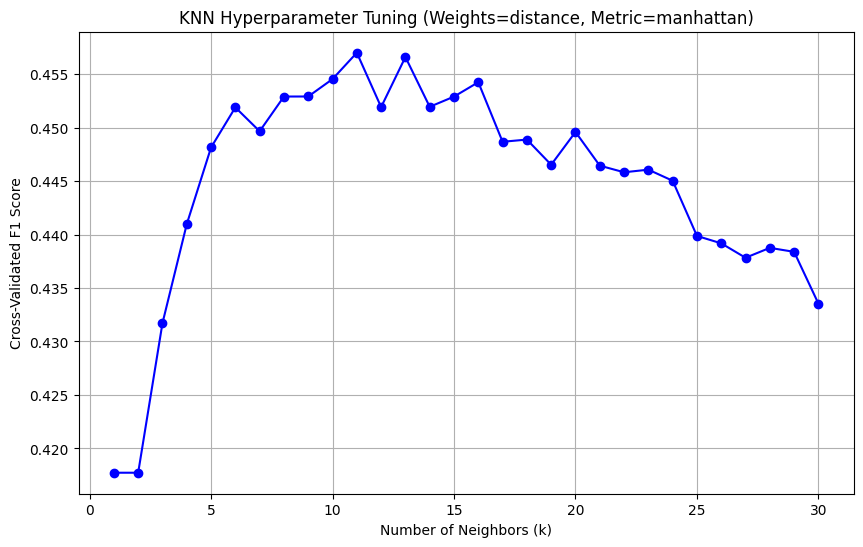

In [243]:
# 1. Define the Parameter Grid
# We will try k from 1 to 30, and both weighting strategies
param_grid_knn = {
    'n_neighbors': range(1, 31),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan'] # Optional: try different distance metrics
}

# 2. Setup GridSearchCV
# We use the same 'cv_strategy' (Stratified K-Fold) you defined earlier
grid_knn = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=param_grid_knn,
    cv=cv_strategy,           # Use your existing 4-fold Stratified split
    scoring='f1_weighted',    # Optimize for F1 Score (good for imbalance)
    n_jobs=-1,                # Use all CPU cores
    verbose=1
)

print("--- Starting Grid Search for KNN ---")
# 3. Fit the Grid Search on the Training Data
grid_knn.fit(X_train, y_train)

# 4. Results
print(f"\n✅ Best Parameters: {grid_knn.best_params_}")
print(f"✅ Best CV F1 Score: {grid_knn.best_score_:.4f}")

# 5. Evaluate on Test Set with Best Estimator
best_knn = grid_knn.best_estimator_
y_test_pred = best_knn.predict(X_test)
test_f1 = f1_score(y_test, y_test_pred, average='weighted')
print(f"✅ Test Set F1 Score: {test_f1:.4f}")

# --- 6. Visualization: K vs. Performance ---
# We extract results to plot the "Elbow Curve"
results_df = pd.DataFrame(grid_knn.cv_results_)

# Filter for the best metric/weight configuration to keep the plot clean
# Let's plot the results for the 'weights' that won
best_weight = grid_knn.best_params_['weights']
best_metric = grid_knn.best_params_['metric']

subset_df = results_df[
    (results_df['param_weights'] == best_weight) & 
    (results_df['param_metric'] == best_metric)
]

plt.figure(figsize=(10, 6))
plt.plot(subset_df['param_n_neighbors'], subset_df['mean_test_score'], marker='o', linestyle='-', color='b')
plt.title(f'KNN Hyperparameter Tuning (Weights={best_weight}, Metric={best_metric})')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Cross-Validated F1 Score')
plt.grid(True)
plt.show()

In [23]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, f1_score

# 1. Initialize the Standard Model (Default Parameters)
gnb = GaussianNB()

# 2. Fit on Training Data
gnb.fit(X_train, y_train)

# 3. Predict on Test Data
y_pred = gnb.predict(X_test)

# 4. Evaluate
print(f"✅ Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"✅ F1 Score (Weighted): {f1_score(y_test, y_pred, average='weighted'):.4f}")

print("\n--- Classification Report ---")
# Use class_names if available from your LabelEncoder, otherwise it defaults to numbers
try:
    target_names = [str(c) for c in le.classes_]
except NameError:
    target_names = None

print(classification_report(y_test, y_pred, target_names=target_names))

✅ Accuracy: 0.1131
✅ F1 Score (Weighted): 0.0691

--- Classification Report ---
              precision    recall  f1-score   support

         0.0       0.10      0.97      0.18       173
         1.0       1.00      0.00      0.00       406
         2.0       0.67      0.00      0.00       866
         3.0       0.56      0.09      0.16       701
         4.0       0.03      0.82      0.05        11

    accuracy                           0.11      2157
   macro avg       0.47      0.38      0.08      2157
weighted avg       0.64      0.11      0.07      2157



--- Starting Decision Tree Hyperparameter Tuning ---
Fitting 4 folds for each of 168 candidates, totalling 672 fits



✅ Best Parameters: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10}
✅ Best CV F1 Score: 0.3255
✅ Test Set F1 Score: 0.3135


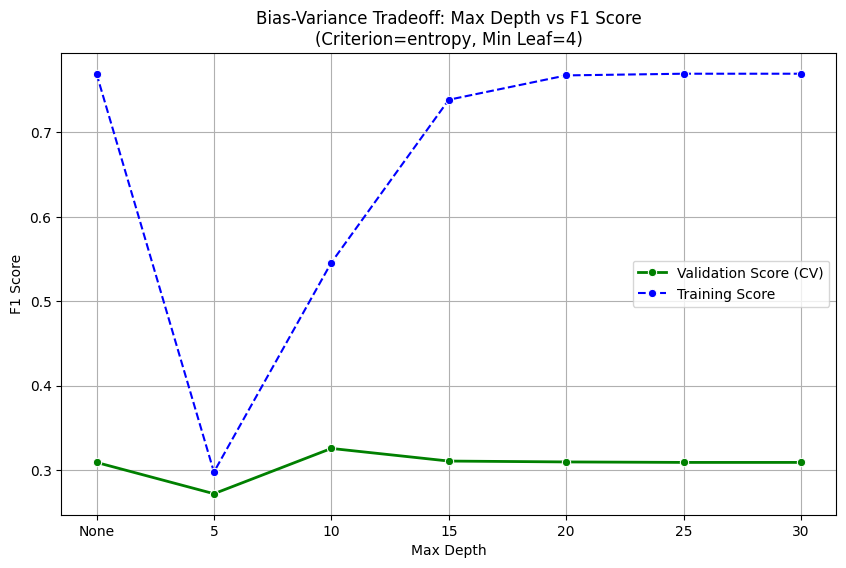

In [91]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score

# --- 1. Define the Parameter Grid ---
param_grid_dt = {
    'criterion': ['gini', 'entropy'],           
    'max_depth': [None, 5, 10, 15, 20, 25, 30], 
    'min_samples_split': [2, 5, 10],            
    'min_samples_leaf': [1, 2, 4, 8]            
}

# --- 2. Setup GridSearchCV (CRITICAL CHANGE HERE) ---
dt_grid = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid_dt,
    cv=cv_strategy,           
    scoring='f1_weighted',    
    n_jobs=-1,
    verbose=1,
    return_train_score=True   # <--- ENABLE THIS to get training scores
)

print("--- Starting Decision Tree Hyperparameter Tuning ---")

# 3. Fit
dt_grid.fit(X_train, y_train)

# 4. Results
print(f"\n✅ Best Parameters: {dt_grid.best_params_}")
print(f"✅ Best CV F1 Score: {dt_grid.best_score_:.4f}")

best_dt = dt_grid.best_estimator_
y_test_pred = best_dt.predict(X_test)
test_f1 = f1_score(y_test, y_test_pred, average='weighted')
print(f"✅ Test Set F1 Score: {test_f1:.4f}")

# --- 5. Visualization: Training vs Validation Curve ---
results_df = pd.DataFrame(dt_grid.cv_results_)

# Filter for the best criterion/leaf/split to isolate the effect of Depth
best_criterion = dt_grid.best_params_['criterion']
best_leaf = dt_grid.best_params_['min_samples_leaf']
best_split = dt_grid.best_params_['min_samples_split']

subset_df = results_df[
    (results_df['param_criterion'] == best_criterion) & 
    (results_df['param_min_samples_leaf'] == best_leaf) &
    (results_df['param_min_samples_split'] == best_split)
].copy()

# Handle 'None' for depth
subset_df['param_max_depth'] = subset_df['param_max_depth'].fillna("None").astype(str)

plt.figure(figsize=(10, 6))

# Plot Validation Score (The one you had)
sns.lineplot(
    data=subset_df, 
    x='param_max_depth', 
    y='mean_test_score', 
    marker='o', 
    label='Validation Score (CV)', 
    color='green',
    linewidth=2
)

# Plot Training Score (The new addition)
sns.lineplot(
    data=subset_df, 
    x='param_max_depth', 
    y='mean_train_score', 
    marker='o', 
    label='Training Score', 
    color='blue',
    linestyle='--' # Dashed line to distinguish it
)

plt.title(f'Bias-Variance Tradeoff: Max Depth vs F1 Score\n(Criterion={best_criterion}, Min Leaf={best_leaf})')
plt.xlabel('Max Depth')
plt.ylabel('F1 Score')
plt.legend()
plt.grid(True)
plt.show()

--- Starting Random Forest Hyperparameter Tuning ---
Fitting 4 folds for each of 96 candidates, totalling 384 fits

✅ Best Parameters: {'bootstrap': False, 'max_depth': None, 'min_samples_split': 2, 'n_estimators': 300}
✅ Best CV F1 Score: 0.5526
✅ Test Set F1 Score: 0.5850


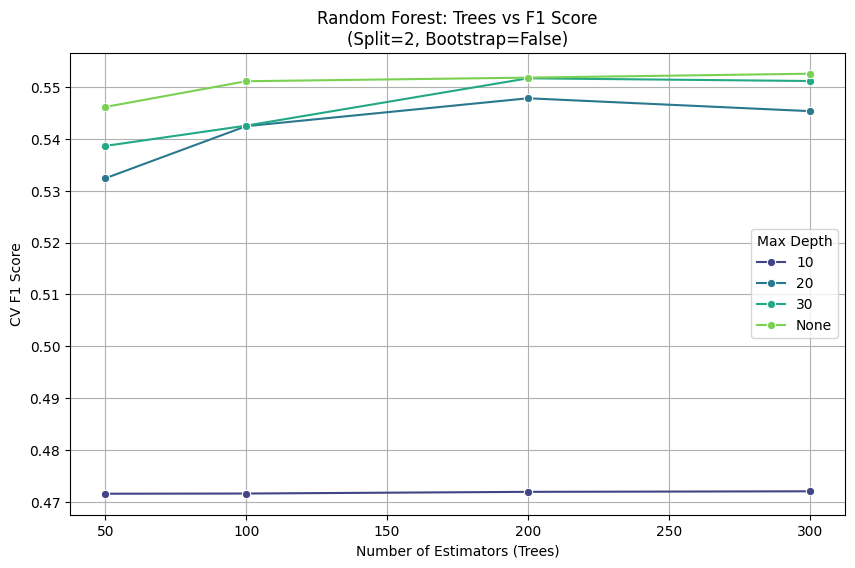

In [245]:
# --- 1. Define the Parameter Grid ---
param_grid_rf = {
    'n_estimators': [50, 100, 200, 300],        # Number of trees in the forest
    'max_depth': [10, 20, 30, None],            # Max depth of the trees
    'min_samples_split': [2, 5, 10],            # Min samples to split a node
    'bootstrap': [True, False]                  # Method for sampling data points
}

# --- 2. Setup GridSearchCV ---
rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid_rf,
    cv=cv_strategy,           # Use your StratifiedKFold strategy
    scoring='f1_weighted',    # Optimize for F1 Score
    n_jobs=-1,
    verbose=1
)

print("--- Starting Random Forest Hyperparameter Tuning ---")

# 3. Fit
rf_grid.fit(X_train, y_train)

# 4. Results
print(f"\n✅ Best Parameters: {rf_grid.best_params_}")
print(f"✅ Best CV F1 Score: {rf_grid.best_score_:.4f}")

best_rf = rf_grid.best_estimator_
y_test_pred = best_rf.predict(X_test)
test_f1 = f1_score(y_test, y_test_pred, average='weighted')

print(f"✅ Test Set F1 Score: {test_f1:.4f}")

# --- 5. Visualization: N_Estimators vs Performance ---
results_df = pd.DataFrame(rf_grid.cv_results_)

# Filter for the best configuration of the OTHER parameters to isolate n_estimators
best_depth = rf_grid.best_params_['max_depth']
best_split = rf_grid.best_params_['min_samples_split']
best_bootstrap = rf_grid.best_params_['bootstrap']

# Create a copy to avoid SettingWithCopyWarning
subset_df = results_df[
    (results_df['param_min_samples_split'] == best_split) &
    (results_df['param_bootstrap'] == best_bootstrap)
].copy()

# Handle 'None' in max_depth for the hue/legend (convert to string)
subset_df['param_max_depth'] = subset_df['param_max_depth'].fillna("None").astype(str)

plt.figure(figsize=(10, 6))
sns.lineplot(
    data=subset_df, 
    x='param_n_estimators', 
    y='mean_test_score', 
    hue='param_max_depth', # Show different lines for different depths
    marker='o',
    palette='viridis'
)

plt.title(f'Random Forest: Trees vs F1 Score\n(Split={best_split}, Bootstrap={best_bootstrap})')
plt.xlabel('Number of Estimators (Trees)')
plt.ylabel('CV F1 Score')
plt.legend(title='Max Depth')
plt.grid(True)
plt.show()

--- Starting XGBoost Hyperparameter Tuning ---
Fitting 4 folds for each of 64 candidates, totalling 256 fits

✅ Best Parameters: {'learning_rate': 0.2, 'max_depth': 10, 'n_estimators': 300}
✅ Best CV F1 Score: 0.6559
✅ Test Set F1 Score: 0.7137


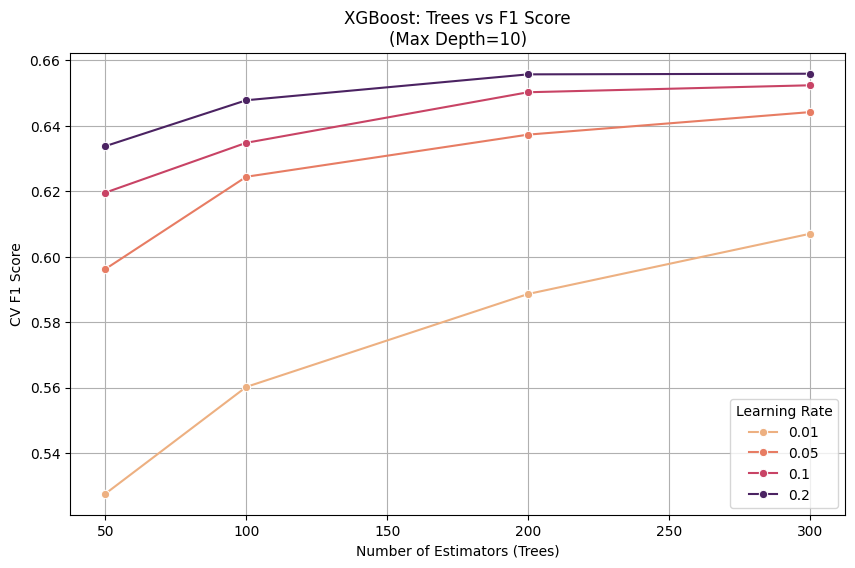

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score

# --- 1. Define the Parameter Grid ---
param_grid_xgb = {
    'n_estimators': [50, 100, 200, 300],      # Number of trees
    'max_depth': [3, 5, 7, 10],               # Tree complexity
    'learning_rate': [0.01, 0.05, 0.1, 0.2]   # Step size
}

# --- 2. Setup GridSearchCV ---
# REMOVED: use_label_encoder=False (this was causing the warning)
xgb_grid = GridSearchCV(
    estimator=xgb.XGBClassifier(
        eval_metric='mlogloss',       # Explicitly set metric to silence other potential warnings
        random_state=42
    ),
    param_grid=param_grid_xgb,
    cv=cv_strategy,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)

print("--- Starting XGBoost Hyperparameter Tuning ---")

# 3. Fit
xgb_grid.fit(X_train, y_train)

# 4. Results
print(f"\n✅ Best Parameters: {xgb_grid.best_params_}")
print(f"✅ Best CV F1 Score: {xgb_grid.best_score_:.4f}")

best_xgb = xgb_grid.best_estimator_
y_test_pred = best_xgb.predict(X_test)
test_f1 = f1_score(y_test, y_test_pred, average='weighted')

print(f"✅ Test Set F1 Score: {test_f1:.4f}")

# --- 5. Visualization ---
results_df = pd.DataFrame(xgb_grid.cv_results_)

# Filter for the best depth to visualize Learning Rate vs Estimators
best_depth = xgb_grid.best_params_['max_depth']

subset_df = results_df[
    results_df['param_max_depth'] == best_depth
].copy()

plt.figure(figsize=(10, 6))
sns.lineplot(
    data=subset_df, 
    x='param_n_estimators', 
    y='mean_test_score', 
    hue='param_learning_rate', 
    marker='o',
    palette='flare'
)

plt.title(f'XGBoost: Trees vs F1 Score\n(Max Depth={best_depth})')
plt.xlabel('Number of Estimators (Trees)')
plt.ylabel('CV F1 Score')
plt.legend(title='Learning Rate')
plt.grid(True)
plt.show()

--- Starting Neural Network Hyperparameter Tuning ---
Total combinations to test: 360


Training MLP Grid:   0%|          | 0/1 [00:00<?, ?it/s]


✅ Best Parameters: {'activation': 'tanh', 'alpha': 0.02, 'hidden_layer_sizes': (150, 100), 'learning_rate_init': 0.001}
✅ Best CV F1 Score: 0.5039
✅ Test Set F1 Score: 0.5204


/tmp/ipykernel_218718/1739933979.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


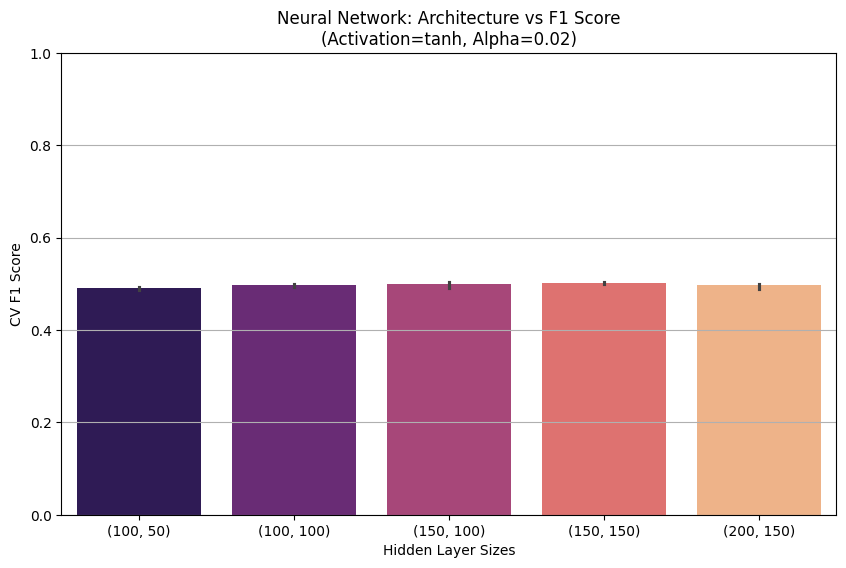

In [254]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score

# --- 1. Define the Parameter Grid ---
# Neural Networks are very sensitive to these parameters
param_grid_mlp = {
    'hidden_layer_sizes': [(100, 50), (100, 100), (150, 100), (150, 150), (200, 150)], # Structure of the network
    'activation': ['tanh', 'relu'],                              # How neurons fire
    'alpha': [0.01, 0.02, 0.025],                              # L2 Regularization (prevents overfitting)
    'learning_rate_init': [0.001, 0.002, 0.005]                          # Initial step size
}

# --- 2. Setup GridSearchCV ---
mlp_grid = GridSearchCV(
    estimator=MLPClassifier(
        max_iter=500,        # Maximum epochs
        early_stopping=True, # Stop if validation score doesn't improve (Critical for speed!)
        random_state=42
    ),
    param_grid=param_grid_mlp,
    cv=cv_strategy,          # Use your StratifiedKFold strategy
    scoring='f1_weighted',   # Optimize for F1 Score
    n_jobs=-1,               # Use all CPU cores
    verbose=0                # Keep silent to use tqdm
)

print("--- Starting Neural Network Hyperparameter Tuning ---")
print(f"Total combinations to test: {len(param_grid_mlp['hidden_layer_sizes']) * len(param_grid_mlp['activation']) * len(param_grid_mlp['alpha']) * len(param_grid_mlp['learning_rate_init']) * N_FOLDS}")

# --- 3. Fit with Progress Bar ---
# Since GridSearchCV is a single function call, we use a simple progress context
with tqdm(total=1, desc="Training MLP Grid") as pbar:
    mlp_grid.fit(X_train, y_train)
    pbar.update(1)

# --- 4. Results ---
print(f"\n✅ Best Parameters: {mlp_grid.best_params_}")
print(f"✅ Best CV F1 Score: {mlp_grid.best_score_:.4f}")

best_mlp = mlp_grid.best_estimator_
y_test_pred = best_mlp.predict(X_test)
test_f1 = f1_score(y_test, y_test_pred, average='weighted')

print(f"✅ Test Set F1 Score: {test_f1:.4f}")

# --- 5. Visualization: Hidden Layers vs Performance ---
results_df = pd.DataFrame(mlp_grid.cv_results_)

# Convert tuple structure (50, 50) to string "(50, 50)" for plotting
results_df['param_hidden_layer_sizes'] = results_df['param_hidden_layer_sizes'].astype(str)

# Filter for the best activation/alpha to visualize structure impact
best_activation = mlp_grid.best_params_['activation']
best_alpha = mlp_grid.best_params_['alpha']

subset_df = results_df[
    (results_df['param_activation'] == best_activation) & 
    (results_df['param_alpha'] == best_alpha)
].copy()

plt.figure(figsize=(10, 6))
sns.barplot(
    data=subset_df, 
    x='param_hidden_layer_sizes', 
    y='mean_test_score', 
    palette='magma'
)

plt.title(f'Neural Network: Architecture vs F1 Score\n(Activation={best_activation}, Alpha={best_alpha})')
plt.xlabel('Hidden Layer Sizes')
plt.ylabel('CV F1 Score')
plt.ylim(0.0, 1.0) # Fix y-axis to see true performance scale
plt.grid(axis='y')
plt.show()

Found 1 tuned models to plot.


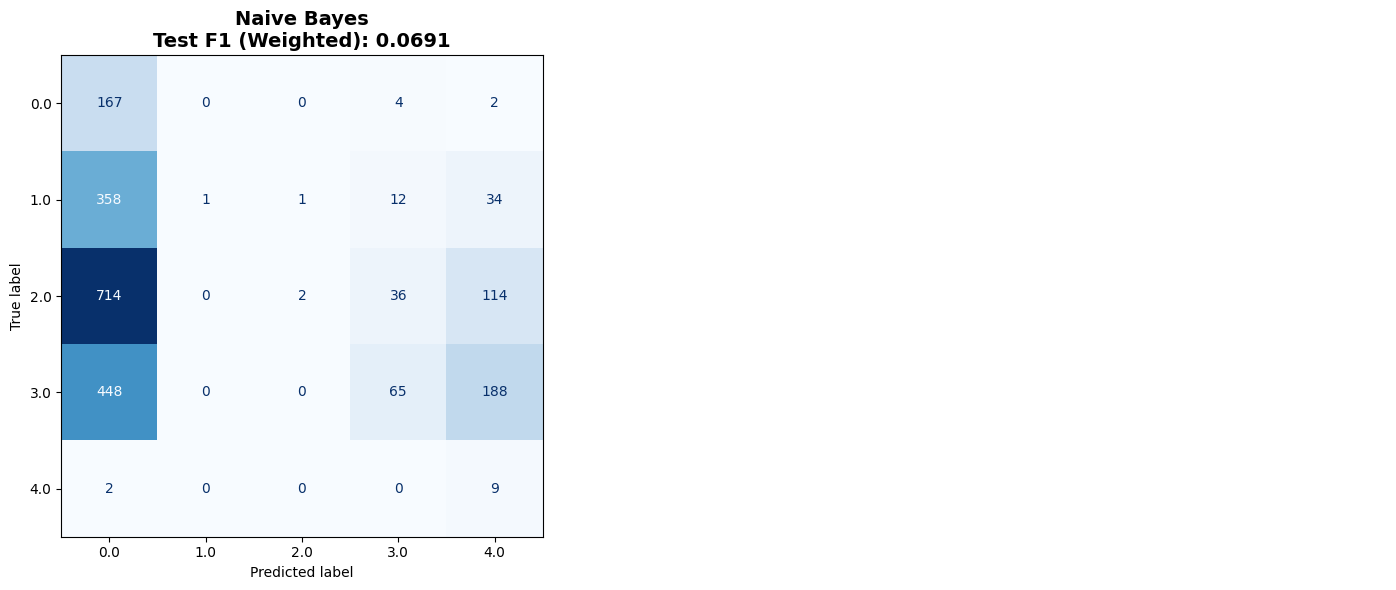

In [24]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, f1_score
import numpy as np

# --- 1. Aggregate Your Best Models ---
# Add or remove models from this list based on what you have actually trained
tuned_models = {
    "KNN": best_knn if 'best_knn' in locals() else None,
    "Naive Bayes": gnb,
    "Decision Tree": best_dt if 'best_dt' in locals() else None,
    "Random Forest": best_rf if 'best_rf' in locals() else None,
    "XGBoost": best_xgb if 'best_xgb' in locals() else None,
    "Neural Network": best_mlp if 'best_mlp' in locals() else None
}

# Remove None values (models that weren't defined)
tuned_models = {k: v for k, v in tuned_models.items() if v is not None}

print(f"Found {len(tuned_models)} tuned models to plot.")

# --- 2. Setup Plotting Grid ---
# Calculate number of rows needed (2 columns wide)
n_models = len(tuned_models)
n_cols = 2
n_rows = (n_models + 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 6 * n_rows))
axes = axes.flatten()

# Get class names as strings (fixes the "float has no len" error)
# We assume 'le' (LabelEncoder) is still available. If not, we use unique y values.
try:
    class_names = [str(c) for c in le.classes_]
except NameError:
    class_names = [str(c) for c in sorted(np.unique(y_test))]

# --- 3. Iterate and Plot ---
for i, (name, model) in enumerate(tuned_models.items()):
    ax = axes[i]
    
    # Predict
    y_pred = model.predict(X_test)
    
    # Calculate Score for Title
    score = f1_score(y_test, y_pred, average='weighted')
    
    # Create Matrix
    cm = confusion_matrix(y_test, y_pred)
    
    # Plot
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    
    ax.set_title(f"{name}\nTest F1 (Weighted): {score:.4f}", fontsize=14, fontweight='bold')
    ax.grid(False) # Turn off grid lines for cleaner look

# Hide any empty subplots if the number of models is odd
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

In [20]:
import joblib
import xgboost as xgb
from tqdm.notebook import tqdm
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

# --- 1. Define Best Hyperparameters ---
# ⚠️ REPLACE these values with the specific "best_params_" you found in your Grid Searches
best_hyperparams = {
    "Decision Tree": {"max_depth": None, "min_samples_leaf": 4, "criterion": "entropy", "min_samples_split": 10},
    "KNN":           {"n_neighbors": 11, "weights": "distance", "metric": "manhattan"},
    "Naive Bayes":   {"var_smoothing": 1e-9}, # GaussianNB usually only has this one
    "Random Forest": {'bootstrap': False, 'max_depth': None, 'min_samples_split': 2, 'n_estimators': 300},
    "XGBoost":       {'learning_rate': 0.2, 'max_depth': 10, 'n_estimators': 300},
    "Neural Network":{'activation': 'tanh', 'alpha': 0.02, 'hidden_layer_sizes': (150, 100), 'learning_rate_init': 0.001}
}

# --- 2. Instantiate Models with Best Params ---
final_models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42, **best_hyperparams["Decision Tree"]),
    
    "KNN": KNeighborsClassifier(**best_hyperparams["KNN"]),
    
    "Naive Bayes": GaussianNB(**best_hyperparams["Naive Bayes"]),
    
    "Random Forest": RandomForestClassifier(random_state=42, **best_hyperparams["Random Forest"]),
    
    "XGBoost": xgb.XGBClassifier(
        eval_metric='mlogloss', 
        random_state=42, 
        **best_hyperparams["XGBoost"]
    ),
    
    "Neural Network": MLPClassifier(
        max_iter=500, 
        early_stopping=True, # Keep this to prevent infinite training loops
        random_state=42, 
        **best_hyperparams["Neural Network"]
    )
}

# --- 3. Fit All Models (Training Loop) ---
print(f"--- Fitting {len(final_models)} Final Models ---")

for name, model in tqdm(final_models.items(), desc="Training Models"):
    # Fit on the FULL training set
    model.fit(X_train, y_train)
    
print("\n✅ All models trained successfully!")

# --- 4. (Optional) Save to Disk ---
# This saves the trained models so you can load them tomorrow without retraining
joblib.dump(final_models, 'final_models_suite.pkl')
print("💾 Models saved to 'final_models_suite.pkl'")

--- Fitting 6 Final Models ---


Training Models:   0%|          | 0/6 [00:00<?, ?it/s]


✅ All models trained successfully!
💾 Models saved to 'final_models_suite.pkl'


📊 SHAP Summary Plot (Global Feature Importance)


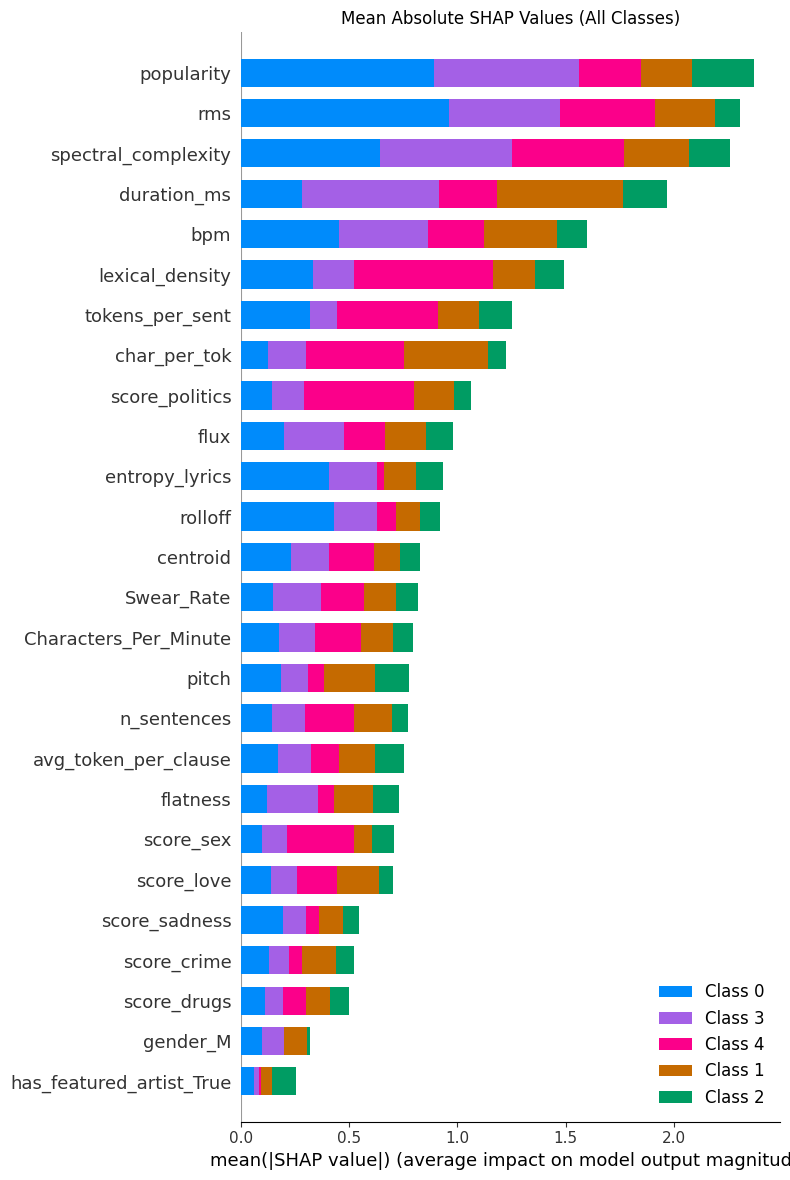

✅ Sliced Shape for Class 0: (2157, 26)


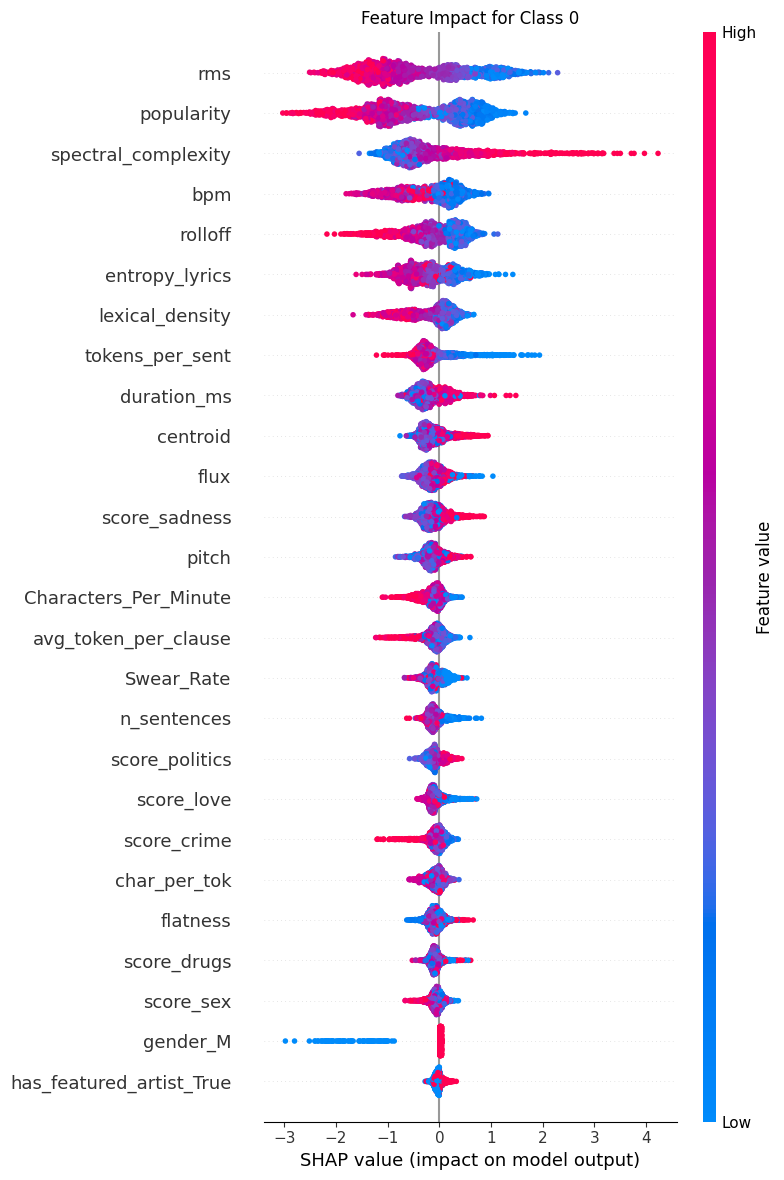

✅ Sliced Shape for Class 1: (2157, 26)


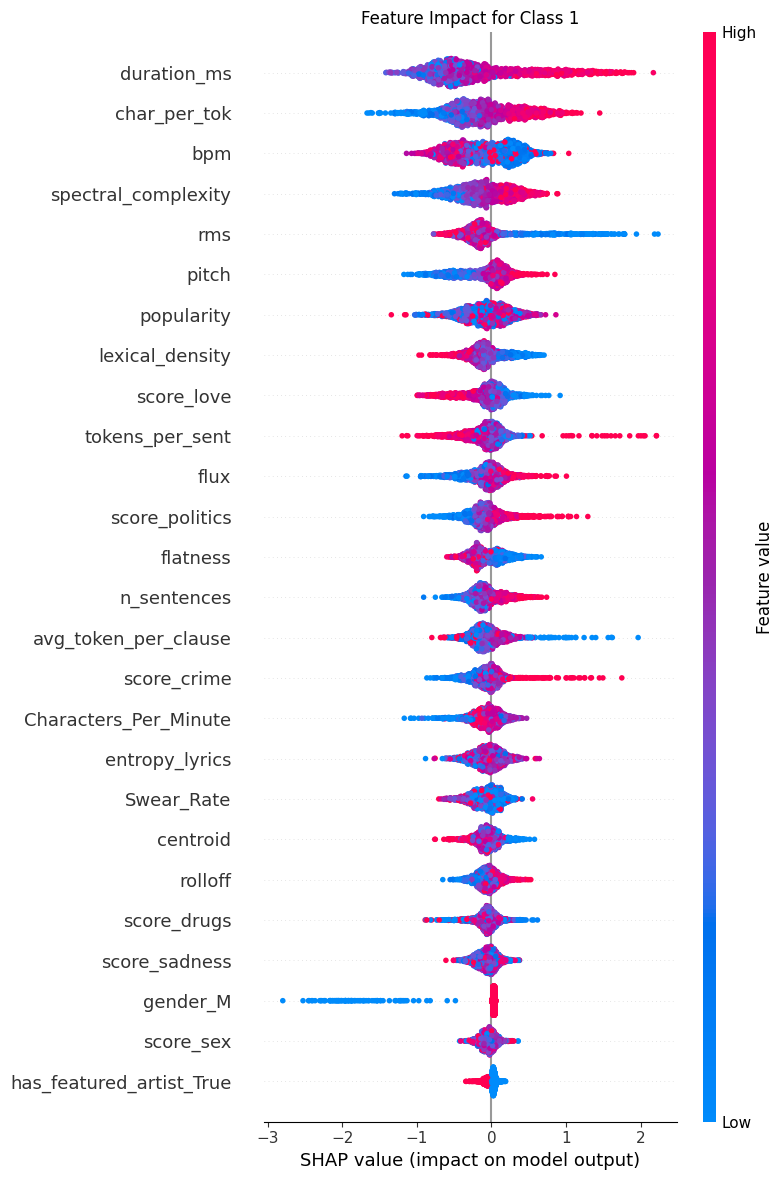

✅ Sliced Shape for Class 2: (2157, 26)


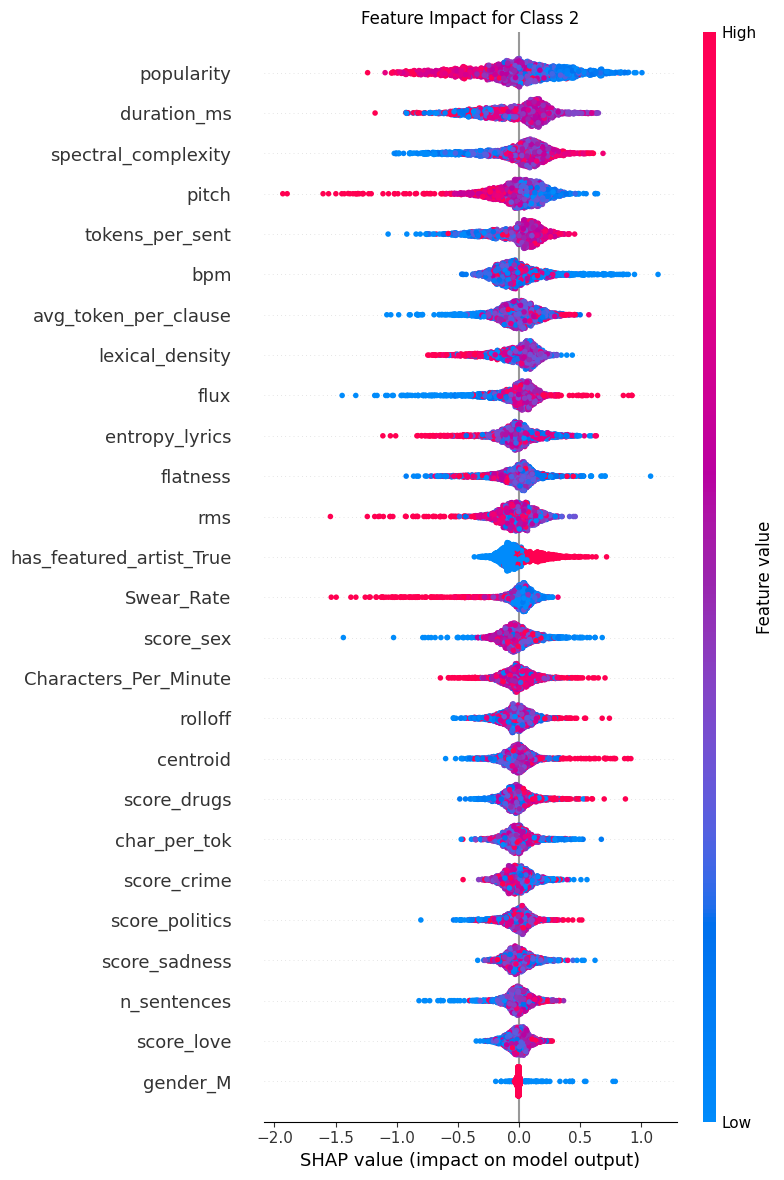

✅ Sliced Shape for Class 3: (2157, 26)


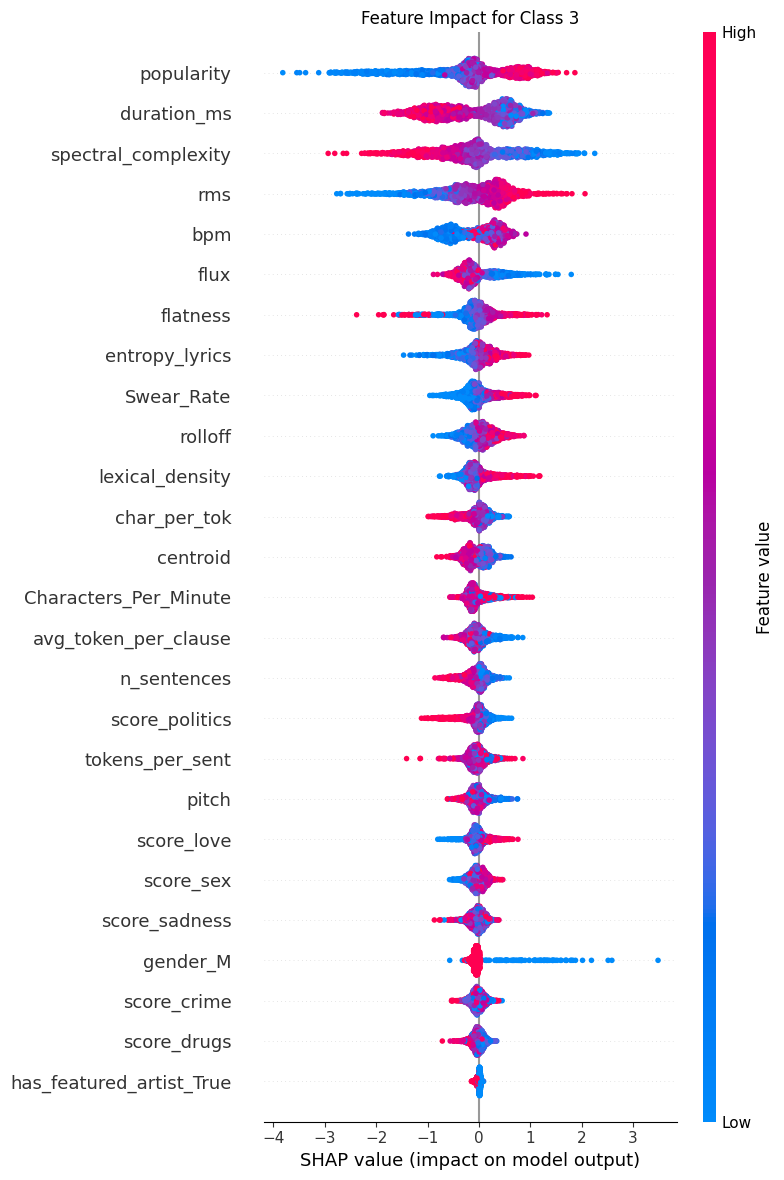

✅ Sliced Shape for Class 4: (2157, 26)


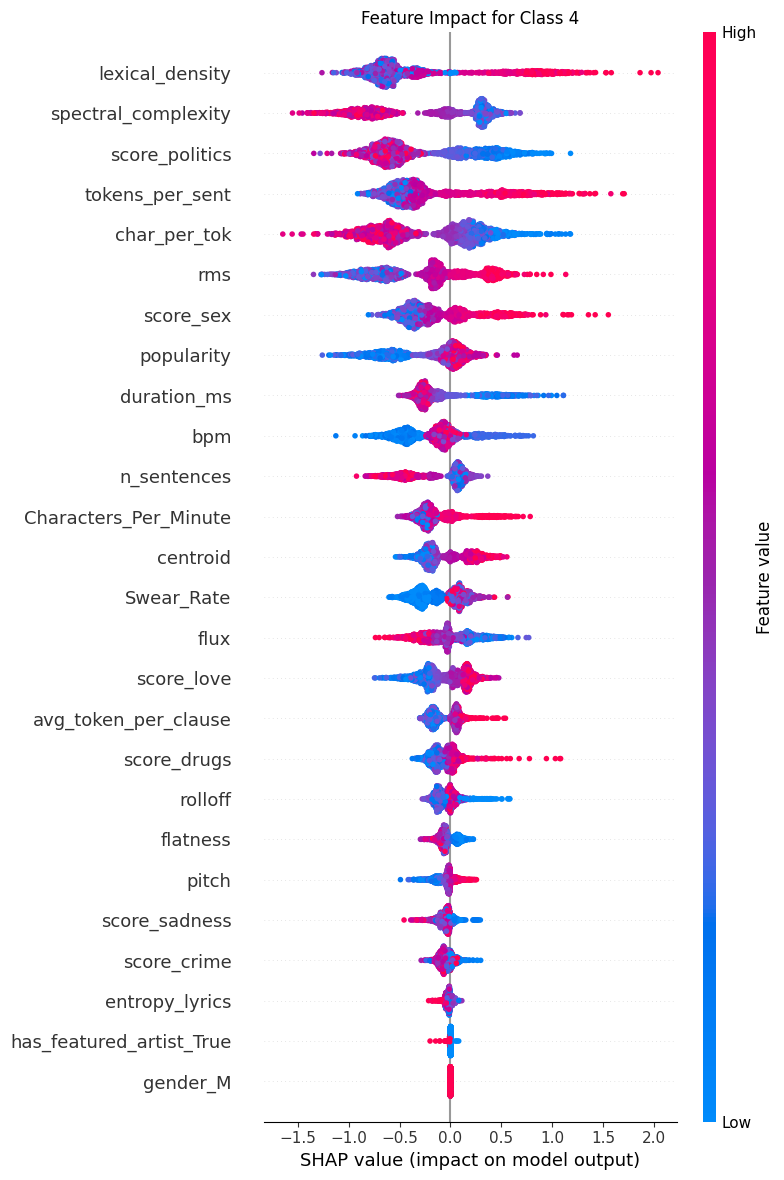

In [21]:
import shap
import matplotlib.pyplot as plt

# 1. Initialize the Explainer
# XGBoost is a tree-based model, so we use TreeExplainer (optimized for trees)

best_xgb = final_models['XGBoost']

explainer = shap.TreeExplainer(best_xgb)

# 2. Calculate SHAP Values
# We use a subsample of X_test (e.g., first 200 rows) to speed up calculation
# If your dataset is small (<2000 rows), you can use the whole X_test
X_sample = X_test
shap_values = explainer.shap_values(X_sample)

# 3. Summary Plot (The "Beeswarm" Plot)
# For Multiclass problems, shap_values is a list of arrays (one per class).
# We can plot the summary for a SPECIFIC class (e.g., Class 0 = Center).
# Or use plot_type="bar" to see the aggregate importance across ALL classes.

print("📊 SHAP Summary Plot (Global Feature Importance)")
plt.figure()
shap.summary_plot(
    shap_values, 
    X_sample, 
    feature_names=COLS,
    max_display=len(COLS),
    plot_type="bar", # 'bar' stacks the importance of all classes
    show=False
)
plt.title("Mean Absolute SHAP Values (All Classes)")
plt.tight_layout()
plt.show()

# 1. Define the class you want to explain (e.g., 0 for the first region)

for i in range (0, 5):
    # 2. Slice the 3D array correctly: [All Samples, All Features, Specific Class]
    # This transforms (2156, 35, 5) -> (2156, 35) matching X_sample
    class_shap_values = shap_values[:, :, i]

    print(f"✅ Sliced Shape for Class {i}: {class_shap_values.shape}")
    # Should output: (2156, 35)

    # 3. Plot
    plt.figure()
    shap.summary_plot(
        class_shap_values, 
        X_sample, 
        feature_names=COLS,
        max_display=len(COLS),
        show=False
    )
    plt.title(f"Feature Impact for Class {i}")
    plt.tight_layout()
    plt.show()